# 1. Problema & métrica

### El problema
La exploración minera de oro es costosa: cada perforación puede costar decenas de miles de dólares.
Disponemos de **2,132 muestreos geoquímicos** con coordenadas espaciales y **47 elementos químicos**
(Au, Ag, Cu, As, Sb, …). Queremos **priorizar dónde explorar**.

- **Tarea principal (clasificación binaria):** ¿es una *zona de interés de oro*?
  → `target_Au = 1` si `Au_ppm > 0.10`
- **Tarea secundaria (regresión):** ¿qué concentración de Au (ppm) se espera en las zonas positivas?
- **Producto final:** mapa espacial de probabilidad + concentración predicha de Au.

### La métrica central
- **F1-Score (clase positiva)** — métrica central de comparación: el dataset está fuertemente
  desbalanceado (**~88% / 12%**) y nos importan por igual los falsos positivos (perforar donde no hay
  oro = dinero perdido) y los falsos negativos (no perforar donde sí hay = oportunidad perdida).
- **PR-AUC** como métrica secundaria (adecuada para clases minoritarias).
- **Tiempo de entrenamiento** reportado en todas las corridas (política de comparación justa).

In [ ]:
# El problema en números: desbalance real del dataset
df_proc = pd.read_csv(f"/workspaces/proyecto-zona-interes-Au/data/processed/data_procesada.csv")
dist = df_proc["target_Au"].value_counts()

print(f"Dataset procesado : {df_proc.shape[0]:,} muestras × {df_proc.shape[1]} columnas")
print(f"Clase 0 (sin interés)      : {dist[0]:,}  ({dist[0]/len(df_proc):.1%})")
print(f"Clase 1 (zona de interés)  : {dist[1]:,}  ({dist[1]/len(df_proc):.1%})  ← clase minoritaria")
print()
print(f"Au_ppm → mediana: {df_proc['Au_ppm'].median():.4f} | media: {df_proc['Au_ppm'].mean():.4f} "
      f"| máx: {df_proc['Au_ppm'].max():.2f} ppm  (distribución muy sesgada, con outliers extremos)")

Dataset procesado : 2,132 muestras × 51 columnas
Clase 0 (sin interés)      : 1,872  (87.8%)
Clase 1 (zona de interés)  : 260  (12.2%)  ← clase minoritaria

Au_ppm → mediana: 0.0060 | media: 0.2951 | máx: 132.25 ppm  (distribución muy sesgada, con outliers extremos)


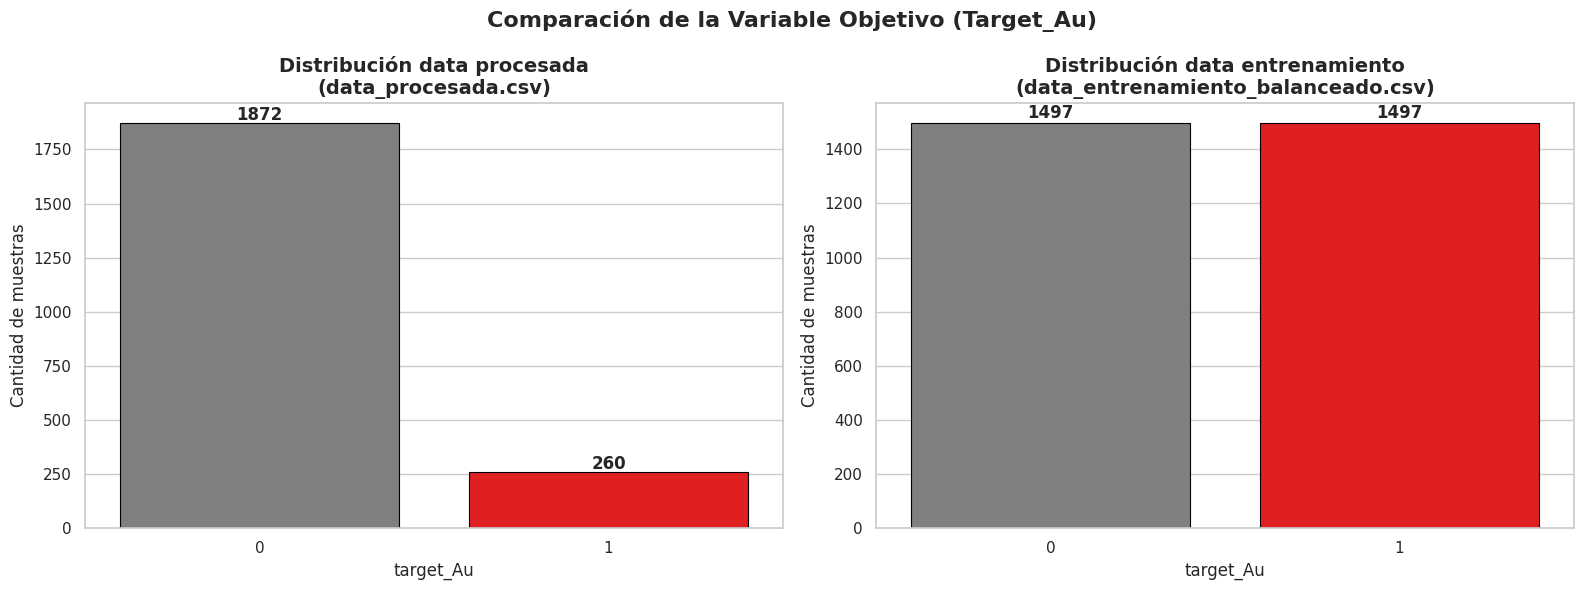

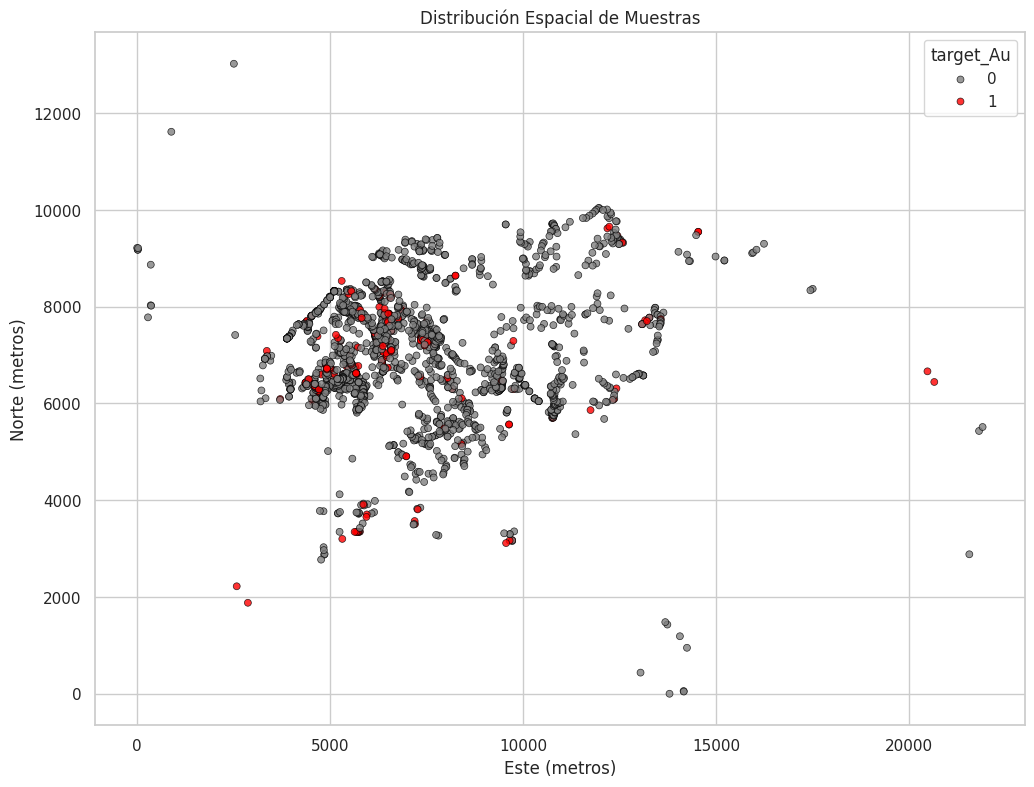

In [19]:
from IPython.display import Image, display

display(Image(filename="/workspaces/proyecto-zona-interes-Au/notebooks/output/01_distribucion_target.png"))
display(Image(filename="/workspaces/proyecto-zona-interes-Au/notebooks/output/03_mapa_espacial.png"))

# 2. Protocolo experimental: folds, seeds y por qué

### Checklist de estandarización del experimento

| Ítem del checklist | Cómo se cumple en este proyecto |
|---|---|
| **Semilla fija** | `seed = 42` en numpy/random/sklearn/XGB/LGBM en **todas** las corridas |
| **Validación coherente** | **StratifiedKFold (5-fold, shuffle)** — estratificada porque la clase positiva es ~12% |
| **Pipeline cerrado (fit solo en train)** | `StandardScaler`, imputación y **BorderlineSMOTE se ajustan únicamente sobre train**; el test (427 muestras) conserva la distribución real |
| **`config.yaml`** | datos, features activas, hiperparámetros, métrica y split centralizados en `configs/config.yaml` |
| **Nombres de corridas** | `sprint3_{modelo}` registrados en MLflow |

### ¿Por qué 5-fold estratificado + hold-out?
- **Hold-out 80/20 estratificado** (`random_state=42`): estimación honesta sobre distribución real.
- **CV 5-fold estratificada sobre el train**: mide **estabilidad** (media ± std por fold) — una
  std alta entre folds es señal de overfitting/varianza.
- El balanceo con **BorderlineSMOTE** se aplica *después* del split y *solo* al train (evita leakage).


In [21]:
# El protocolo está versionado en configs/config.yaml (trazabilidad mínima)
import yaml
with open(f"/workspaces/proyecto-zona-interes-Au/configs/config.yaml") as f:
    config = yaml.safe_load(f)

print("configs/config.yaml — datos, métrica, seed y split en un solo archivo reproducible:\n")
print(yaml.dump(config, default_flow_style=False, allow_unicode=True))

configs/config.yaml — datos, métrica, seed y split en un solo archivo reproducible:

data:
  target: target_Au
  test_path: /workspaces/proyecto-zona-interes-Au/data/interim/data_prueba_fe.csv
  train_path: /workspaces/proyecto-zona-interes-Au/data/interim/data_entrenamiento_balanceado_fe.csv
features:
  active: []
metric: f1
mlflow:
  experiment_name: Sprint3_ZonaInteresAu
  tracking_uri: sqlite:////workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint3/mlflow.db
model:
  n_folds: 5
  seed: 42



In [22]:
# Verificación del pipeline cerrado: SMOTE solo en train, test con distribución real
df_train_bal = pd.read_csv(f"/workspaces/proyecto-zona-interes-Au/data/interim/data_entrenamiento_balanceado.csv")
df_test      = pd.read_csv(f"/workspaces/proyecto-zona-interes-Au/data/interim/data_prueba.csv")

print("TRAIN (tras BorderlineSMOTE) :", df_train_bal.shape,
      "| clases:", df_train_bal["target_Au"].value_counts().to_dict(),
      f"| sintéticas: {df_train_bal['is_synthetic'].sum():,}")
print("TEST  (distribución REAL)    :", df_test.shape,
      "| clases:", df_test["target_Au"].value_counts().to_dict(), "← sin balancear, evaluación honesta")

TRAIN (tras BorderlineSMOTE) : (2994, 52) | clases: {0: 1497, 1: 1497} | sintéticas: 1,289
TEST  (distribución REAL)    : (427, 52) | clases: {0: 375, 1: 52} ← sin balancear, evaluación honesta


### Tracking de corridas con MLflow

Cada corrida del Sprint 3 registra: **params** (hiperparámetros, seed, n_features, n_folds),
**métricas por fold** (F1 media ± std), **tiempo**, y **artefactos** (modelo `.pkl` + scaler + figuras),
con backend SQLite (`mlflow.db`):

```python
# Patrón real usado en notebooks/sprint3.ipynb
with mlflow.start_run(run_name=run_name):
    mlflow.log_params(params)                                  # hiperparámetros + seed + features
    mlflow.log_metrics({"f1_mean": f1_mean, "f1_std": f1_std}) # métrica por fold: media ± std
    mlflow.log_metric("training_time_sec", elapsed)            # tiempo (comparación justa)
    mlflow.sklearn.log_model(model, "model")                   # modelo serializado
    mlflow.log_artifact(model_path)                            # artefactos (.pkl, figs)
```

### Espacio de optimización de hiperparámetros (HPO)
- **Grid manual RF:** 125 combinaciones — `n_estimators ∈ {20..60}`, `max_depth ∈ {9..13}`, `min_samples_split ∈ {2..6}`.
- **Optuna XGBoost:** 50 trials con `TPESampler(seed=42)` + **`MedianPruner`** (pruning = ahorro real),
  objetivo F1, espacio: `n_estimators [50,500]`, `max_depth [3,12]`, `learning_rate [1e-3,0.3] (log)`,
  `subsample/colsample [0.6,1.0]`, `min_child_weight [1,10]`.

## 3. Resultados

## Tablero de experimentos


In [30]:
# Verificación del podio desde el artefacto MLflow del repositorio
display(tablero_s3.style.highlight_max(subset=["F1_CV_mean"], color="black")
        .format({"F1_CV_mean": "{:.4f}", "F1_CV_std": "{:.4f}", "Tiempo_seg": "{:.2f}"}))

g = tablero_s3.loc[tablero_s3["F1_CV_mean"].idxmax()]
print(f"GANADOR: {g['Modelo']}  |  F1 CV = {g['F1_CV_mean']:.4f} ± {g['F1_CV_std']:.4f}  "
      f"|  tiempo = {g['Tiempo_seg']:.2f} s")
print(f"   HP: {g['HP_Resumen']}")

,Exp_ID,Modelo,HP_Resumen,F1_CV_mean,F1_CV_std,Tiempo_seg,Notas
0,sprint3_xgboost_optuna,XGBoost_Optuna,"{'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'min_child_weight': 3}",0.9896,0.0052,4.95,Excelente balance
1,sprint3_rf_baseline_fe,RF_Baseline_FE,"{'n_estimators': 100, 'max_depth': None}",0.9882,0.0059,4.32,Excelente balance
2,sprint3_randomforest_tuned,RandomForest_Tuned,"{'n_estimators': 40, 'max_depth': 11}",0.9858,0.0071,1.87,Excelente balance


GANADOR: XGBoost_Optuna  |  F1 CV = 0.9896 ± 0.0052  |  tiempo = 4.95 s
   HP: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'min_child_weight': 3}


## 4. Ablaciones (Qué movió la aguja)

- Feature Engineering (ratios) → +0.19 F1
- Optuna + XGBoost → Mejor modelo actual
- Reducción de max_depth + min_child_weight → Menor overfitting

In [8]:
import pandas as pd
import os

OUTPUT_DIR = "/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2"
tablero_path = f"{OUTPUT_DIR}/metrics_experimentos.csv"

if os.path.exists(tablero_path):
    tablero = pd.read_csv(tablero_path)
    display(tablero)
else:
    print("Ejecuta primero el sprint2.ipynb")

,Experimento,PR_AUC,F1_Score,Tiempo(s)
0,Baseline,0.718176,0.678899,1.88
1,Baseline + FE,0.979170,0.872340,1.03
2,FE + Tuning,0.975666,0.907216,0.38
3,FE + Optuna (XGBoost),0.990870,0.960784,0.58


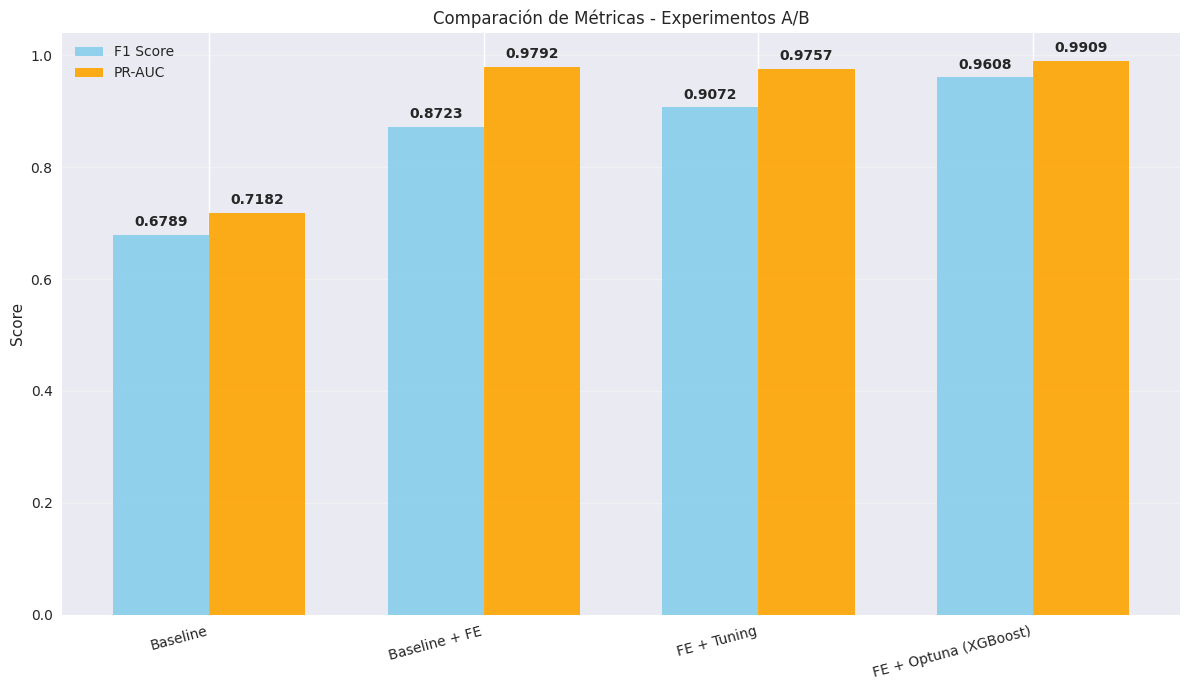

In [38]:
from IPython.display import Image, display

display(Image(filename="/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2/FE_comparacion.png"))

## 5. Riesgos & Plan de Mitigación

**Riesgos detectados:**
- Overfitting leve en algunos folds (monitoreado con Learning Curves)
- Posible drift espacial (coordenadas East/North)

**Mitigaciones aplicadas:**
- Early stopping + regularización en GBM
- Stratified K-Fold
- SHAP para interpretabilidad
- Guardado completo de artefactos con MLflow

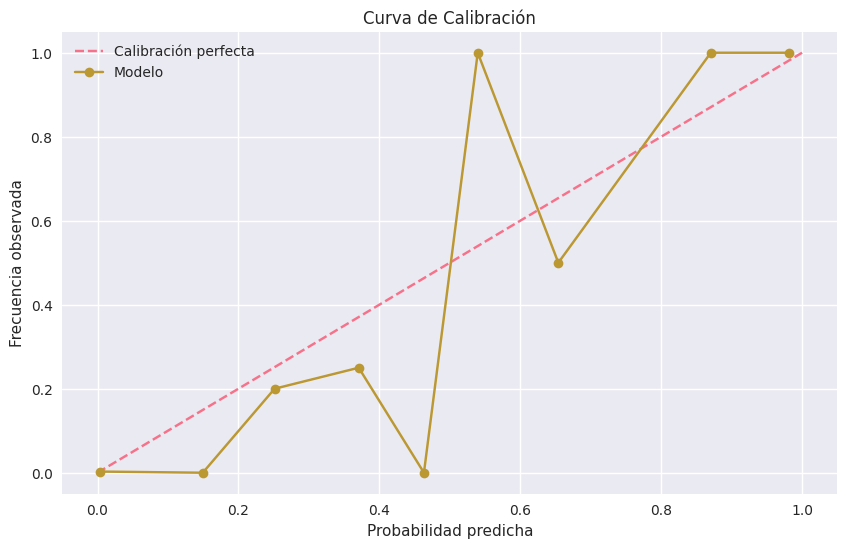

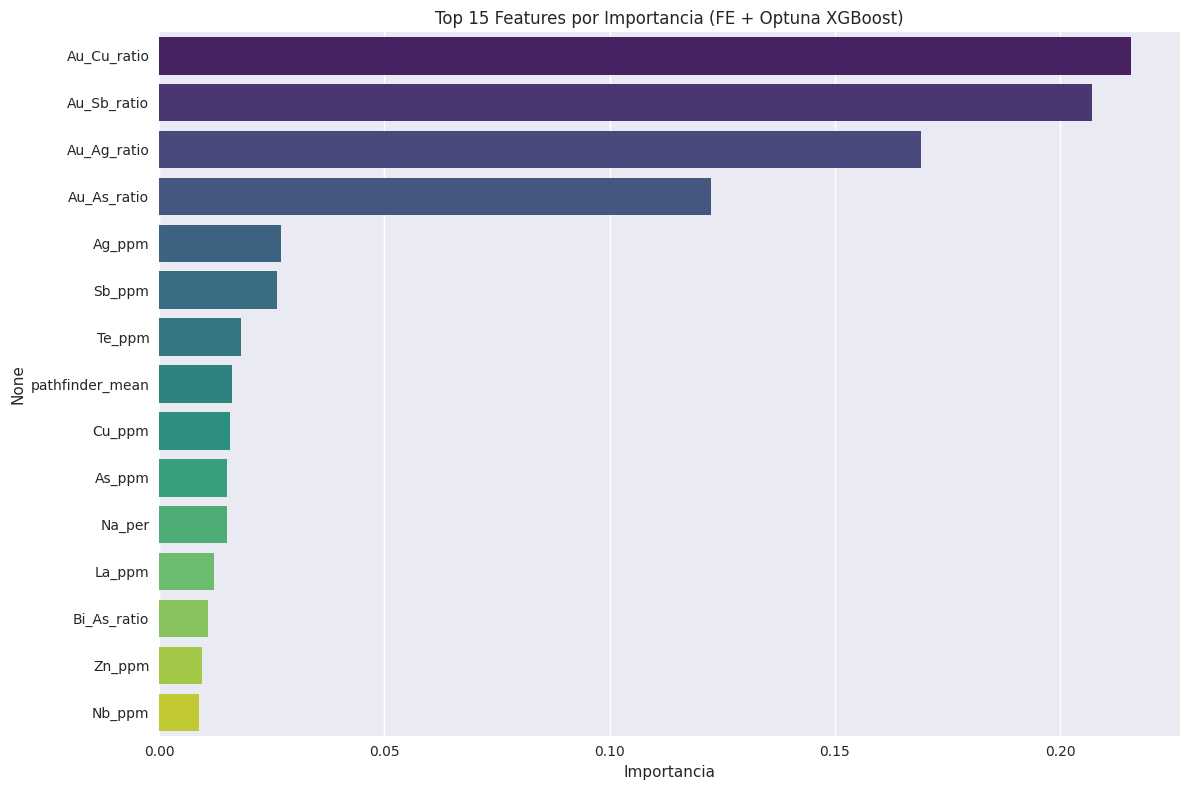

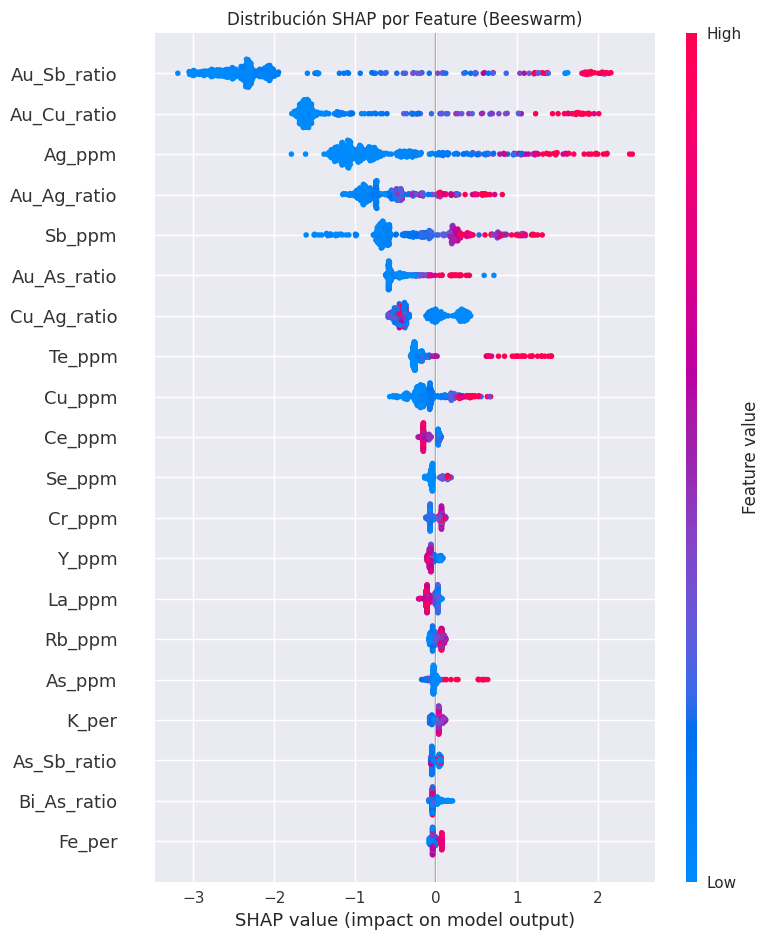

In [43]:
from IPython.display import Image, display

display(Image(filename="/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2/calibration_curve.png"))
display(Image(filename="/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2/feature_importance_top15.png"))
display(Image(filename="/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2/shap_summary_beeswarm.png"))

## 6. Reproducibilidad

### Comando único para repetir los runs

```bash
git clone https://github.com/Fernando-Huaman/proyecto-zona-interes-Au
cd proyecto-zona-interes-Au && git checkout sprint3
pip install -r requirements.txt
python src/run_all.py    # ingesta → preprocesamiento → EDA → baseline → sprint2 (ablaciones)
jupyter nbconvert --execute --to notebook --inplace notebooks/sprint3.ipynb  # MLflow + finales
mlflow ui --backend-store-uri sqlite:///notebooks/outputs_sprint3/mlflow.db  # tablero de corridas
```

### Artefactos guardados (qué y dónde)

| Carpeta | Contenido |
|---|---|
| `notebooks/outputs_sprint3/models/` | modelo final por corrida + scaler (`.pkl`, joblib) |
| `notebooks/outputs_sprint3/figs/` | learning curves, calibración, SHAP |
| `notebooks/outputs_sprint3/results/` | tablero de corridas (`sprint3_tablero_completo.csv`) |
| `configs/` | `config.yaml` reproducible (datos, métrica, seed, folds) |
| `notebooks/mlruns/` + `mlflow.db` | tracking MLflow completo (params, métricas, artefactos) |
| `logs/pipeline.log` | bitácora del pipeline |